#🛠️ Preparación de los Datos

In [3]:
#importando las bibliotecas a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Leyendo el dataset
url="https://raw.githubusercontent.com/SergioptsUSCO/Challenge-Telecom-X---Parte-2/refs/heads/main/datos.csv"
df = pd.read_csv(url,index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 
 17  

In [5]:
#Eliminando columnas innecesarias
df=df.drop(columns=["customerID","charges.daily"])

In [6]:
#Tratando valores nulos
df["Charges.Total"]=df['Charges.Total'].fillna(0)
df['gender']

,gender
0,Female
1,Male
2,Male
3,Male
4,Female
...,...
7262,Female
7263,Male
7264,Male
7265,Male


In [7]:
#Codificando variables categóricas
df_codificados = pd.get_dummies(df, drop_first=True)
df_codificados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7267 non-null   int64  
 1   SeniorCitizen                          7267 non-null   int64  
 2   Partner                                7267 non-null   int64  
 3   Dependents                             7267 non-null   int64  
 4   tenure                                 7267 non-null   int64  
 5   PhoneService                           7267 non-null   int64  
 6   PaperlessBilling                       7267 non-null   int64  
 7   Charges.Monthly                        7267 non-null   float64
 8   Charges.Total                          7267 non-null   float64
 9   gender_Male                            7267 non-null   bool   
 10  MultipleLines_1                        7267 non-null   bool   
 11  MultipleL

In [8]:
#Proporcion de Cancelación(Churn)
df_codificados.Churn.value_counts()    # Se puede ver que hay una gran proporcion de clientes que decidieron no cancelar

,count
Churn,
0,5398
1,1869


In [9]:
#Balanceando las clases en Churn
from imblearn.over_sampling import SMOTE     #despues de analizar las opciones, decidí usar SMOTE para balancear las clases de Churn
X = df_codificados.drop("Churn", axis=1)
y = df_codificados["Churn"]
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
y_balanced.value_counts()

,count
Churn,
0,5398
1,5398


In [10]:
#Normalizando y estandarizando los datos
columnas=df_codificados.columns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler_standard=StandardScaler()
data_padre=pd.DataFrame(scaler_standard.fit_transform(df_codificados),columns=columnas)
data_padre.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.588421,-0.440736,1.032309,1.527075,-0.950200,0.32829,0.828063,0.029206,-0.742291,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,1.945268,-0.561723,-0.524534,-0.712075,1.834275
1,-0.588421,-0.440736,-0.968702,-0.654847,-0.950200,0.32829,-1.207638,-0.159990,-0.764729,0.988643,...,-0.527306,-0.789421,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275
2,1.699463,-0.440736,-0.968702,-0.654847,-1.153700,0.32829,0.828063,0.304702,-0.880026,0.988643,...,-0.527306,-0.789421,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
3,1.699463,2.268932,1.032309,-0.654847,-0.787401,0.32829,0.828063,1.104635,-0.458160,0.988643,...,-0.527306,1.266752,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
4,1.699463,2.268932,1.032309,-0.654847,-1.194400,0.32829,0.828063,0.636624,-0.885955,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275


In [11]:
#Normalizando
scaler_MinMax=MinMaxScaler()
data_norm=pd.DataFrame(scaler_standard.fit_transform(df_codificados),columns=columnas)
data_norm.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.588421,-0.440736,1.032309,1.527075,-0.950200,0.32829,0.828063,0.029206,-0.742291,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,1.945268,-0.561723,-0.524534,-0.712075,1.834275
1,-0.588421,-0.440736,-0.968702,-0.654847,-0.950200,0.32829,-1.207638,-0.159990,-0.764729,0.988643,...,-0.527306,-0.789421,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275
2,1.699463,-0.440736,-0.968702,-0.654847,-1.153700,0.32829,0.828063,0.304702,-0.880026,0.988643,...,-0.527306,-0.789421,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
3,1.699463,2.268932,1.032309,-0.654847,-0.787401,0.32829,0.828063,1.104635,-0.458160,0.988643,...,-0.527306,1.266752,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
4,1.699463,2.268932,1.032309,-0.654847,-1.194400,0.32829,0.828063,0.636624,-0.885955,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275


#🎯 Correlación y Selección de Variables

In [12]:
#Hallando correlacion entre variables
correlaciones=df_codificados.corr()

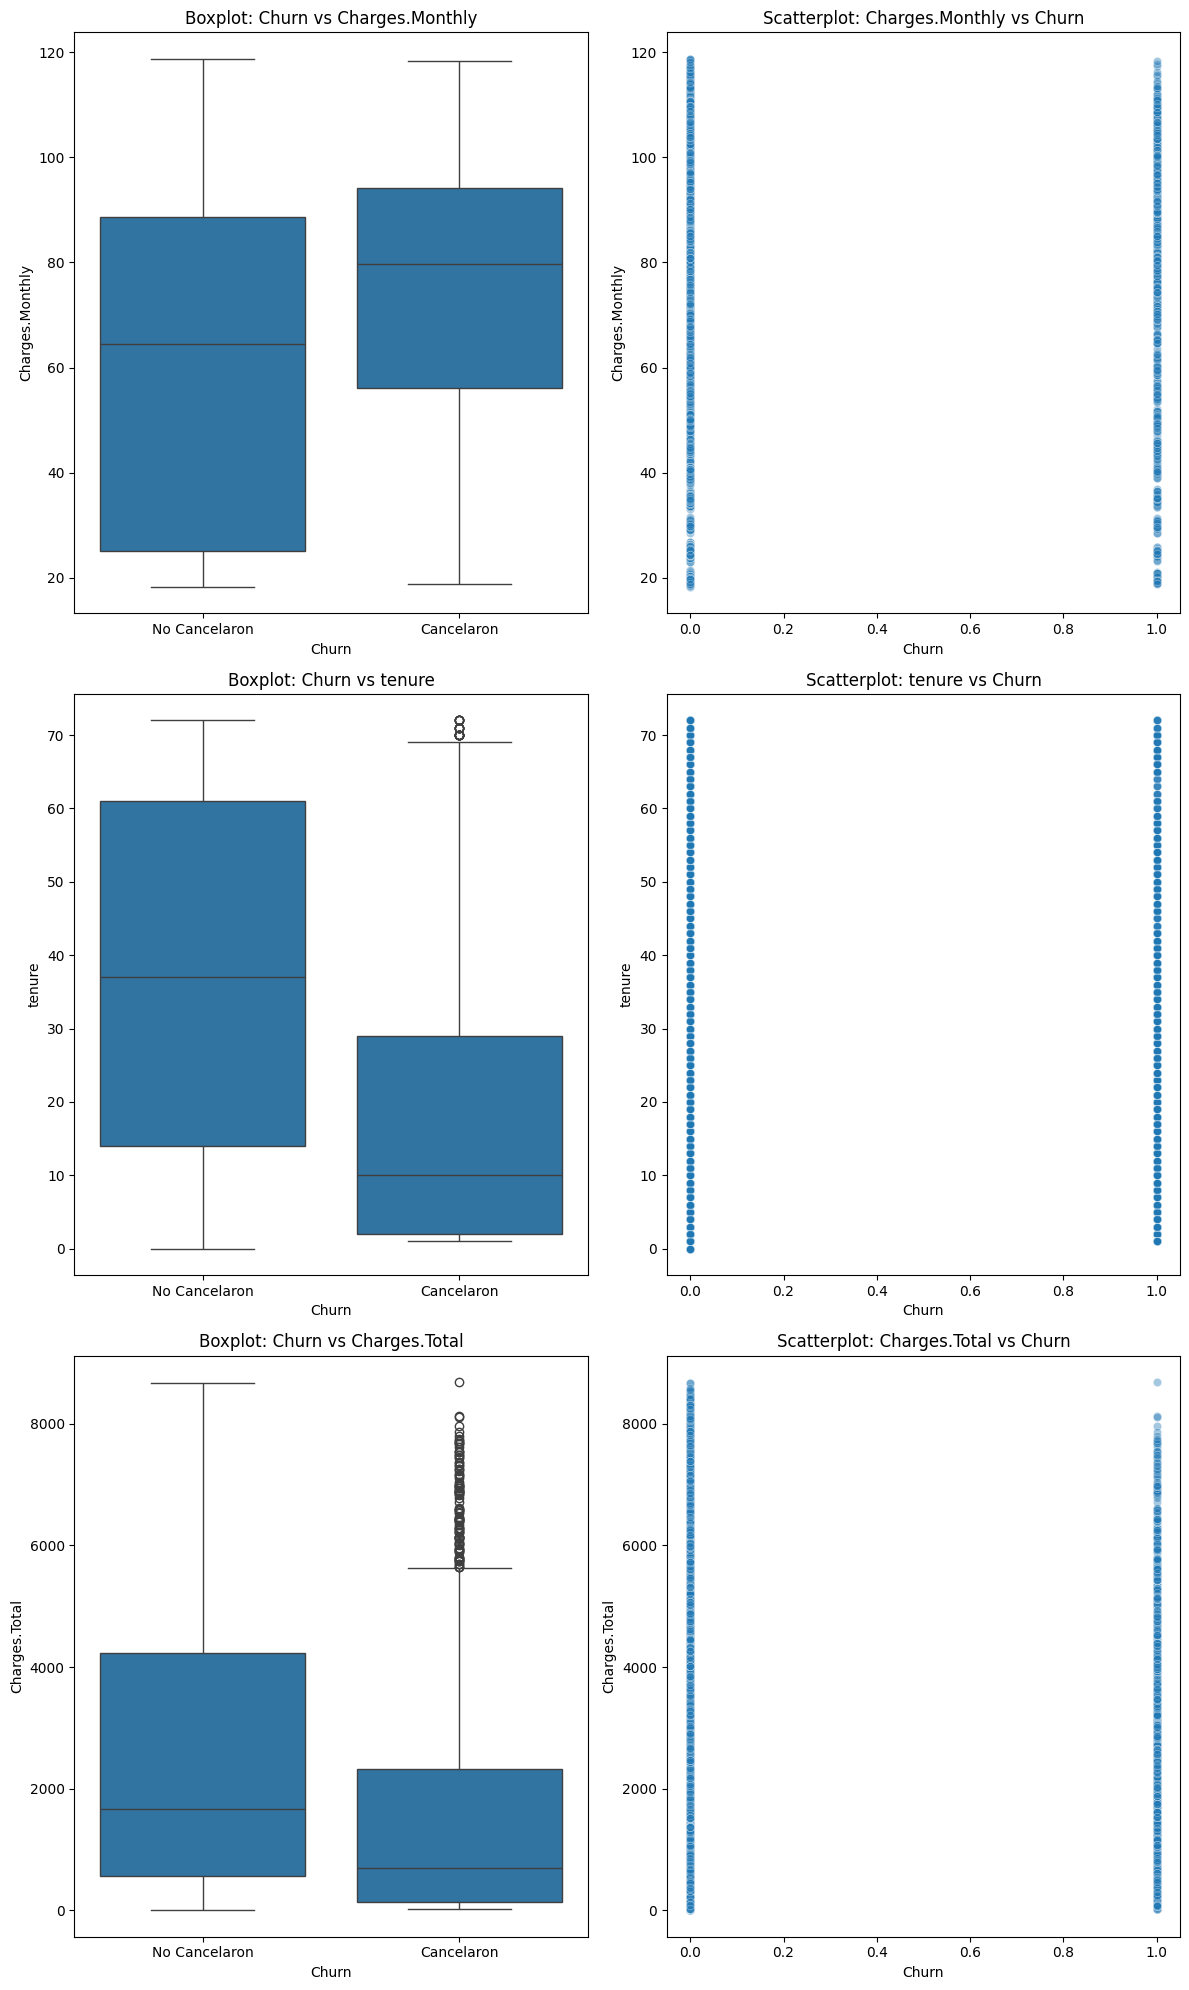

In [13]:
#Graficando las relaciones con mayor correlacion con la variable resultante
variables_explicativas = ["Charges.Monthly", "tenure", "Charges.Total"]

fig, axes = plt.subplots(3, 2, figsize=(12, 20))

for i, var in enumerate(variables_explicativas):

    # Boxplot
    sns.boxplot(x="Churn", y=var, data=df_codificados, ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot: Churn vs {var}")
    axes[i, 0].set_xticks([0,1])
    axes[i, 0].set_xticklabels(["No Cancelaron", "Cancelaron"])

    # Scatterplot
    sns.scatterplot(y=var, x="Churn", data=df_codificados, ax=axes[i, 1], alpha=0.4)
    axes[i, 1].set_title(f"Scatterplot: {var} vs Churn")

plt.tight_layout()
plt.show()

#🤖 Modelado Predictivo

In [14]:
#Dividiendo el conjunto de datos
from sklearn.model_selection import train_test_split

In [15]:
#Usando la funcion train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_balanced,y_balanced,test_size=0.2,random_state=42)
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución en entrenamiento:
Churn
0    0.502316
1    0.497684
Name: proportion, dtype: float64

Distribución en prueba:
Churn
1    0.509259
0    0.490741
Name: proportion, dtype: float64


In [16]:
#Creacion de modelos de ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

modelo_knn=KNeighborsClassifier(n_neighbors=5)
modelo_rf=RandomForestClassifier(random_state=42)

In [17]:
#Entrenamiento de los modelos
#KNN
X_train_scaled = scaler_standard.fit_transform(X_train)
X_test_scaled = scaler_standard.transform(X_test)

modelo_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [18]:
#RF
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
#Mirando métricas
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
#Predicciones
y_pred_knn = modelo_knn.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

In [21]:
print("Reporte KNN")
print(classification_report(y_test, y_pred_knn))

print("Reporte Random Forest")
print(classification_report(y_test, y_pred_rf))

Reporte KNN
              precision    recall  f1-score   support

           0       0.82      0.72      0.77      1060
           1       0.76      0.84      0.80      1100

    accuracy                           0.78      2160
   macro avg       0.79      0.78      0.78      2160
weighted avg       0.79      0.78      0.78      2160

Reporte Random Forest
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1060
           1       0.83      0.86      0.84      1100

    accuracy                           0.84      2160
   macro avg       0.84      0.84      0.84      2160
weighted avg       0.84      0.84      0.84      2160



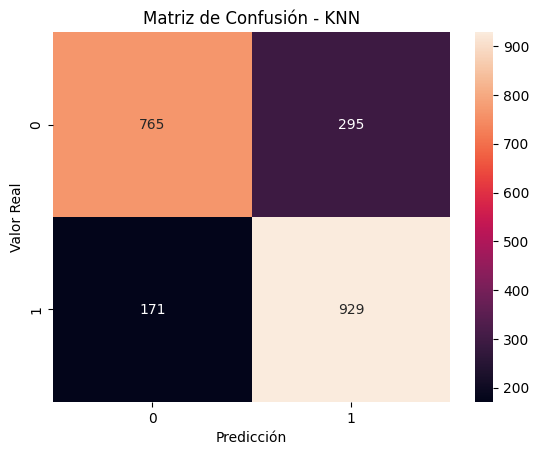

In [22]:
#Confussion Matrix
#KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt="d")
plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

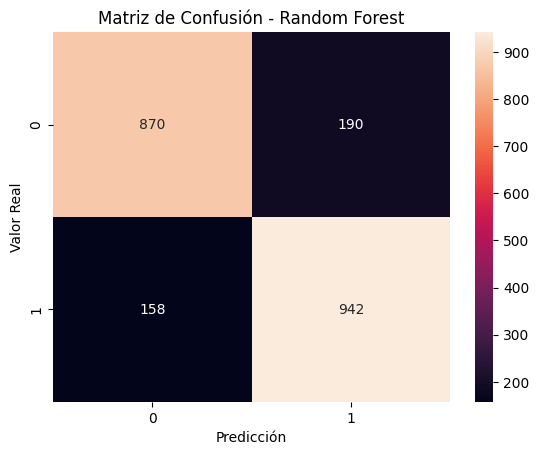

In [23]:
#RF
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

#Ambos modelos muestran una buena capacidad de generalización para predecir la cancelación de clientes. Sin embargo, el modelo Random Forest presenta un mejor desempeño, ya que reduce tanto los falsos positivos como los falsos negativos en comparación con KNN. Esto indica que Random Forest logra una clasificación más precisa de los clientes que cancelan y los que permanecen en la empresa.

#Ninguno de los modelos presenta señales graves de overfitting o underfitting. Sin embargo:

#-Random Forest muestra mejor capacidad de generalización.

#-KNN podría estar ligeramente limitado por la elección de sus hiperparámetros, lo que sugiere un posible underfitting leve.

#En general, Random Forest resulta ser el modelo más adecuado para este problema de predicción de churn.

#📋 Interpretación y Conclusiones

In [24]:
#importancia de las variables del modelo KNN
importancia = modelo_rf.feature_importances_

features = X_train.columns

importancia_df = pd.DataFrame({
    "Variable": features,
    "Importancia": importancia
})

importancia_df = importancia_df.sort_values(by="Importancia", ascending=False)

print(importancia_df.head(10))

                          Variable  Importancia
7                    Charges.Total     0.159868
3                           tenure     0.155207
6                  Charges.Monthly     0.138972
28  PaymentMethod_Electronic check     0.101532
11     InternetService_Fiber optic     0.050289
26               Contract_Two year     0.034243
2                       Dependents     0.033266
1                          Partner     0.031416
8                      gender_Male     0.024083
9                  MultipleLines_1     0.023257


#El modelo Random Forest permite identificar las variables más relevantes en la predicción de la cancelación. Entre las variables más influyentes se encuentran la antigüedad del cliente (tenure), los cargos mensuales y el tipo de contrato. Estas variables parecen tener un impacto significativo en la probabilidad de que un cliente decida cancelar el servicio.

#Informe de Análisis Predictivo de Cancelación de Clientes (Churn)
##Introducción

El objetivo de este análisis fue desarrollar modelos de Machine Learning capaces de predecir la cancelación de clientes (Churn) en la empresa Telecom X. La cancelación de clientes representa un problema importante para las compañías de telecomunicaciones, ya que implica pérdida de ingresos y mayores costos para adquirir nuevos clientes.

Para abordar este problema, se aplicaron técnicas de preprocesamiento de datos, balanceo de clases mediante SMOTE y entrenamiento de modelos de clasificación. Los modelos seleccionados para este análisis fueron K-Nearest Neighbors (KNN) y Random Forest, los cuales permiten identificar patrones en los datos y predecir la probabilidad de cancelación de los clientes.

##Preparación de los Datos

Antes de entrenar los modelos se realizaron varias etapas de preparación de los datos:

-Eliminación de variables irrelevantes como customerID.

-Codificación de variables categóricas mediante Get_dummies.

-Balanceo de la variable objetivo Churn utilizando la técnica SMOTE, con el fin de evitar sesgos en el entrenamiento del modelo.

-División del conjunto de datos en datos de entrenamiento y prueba para evaluar la capacidad de generalización de los modelos.

-Normalización de los datos para el modelo KNN, ya que este algoritmo depende de distancias entre observaciones.

Estas etapas permitieron obtener un conjunto de datos adecuado para el entrenamiento y evaluación de los modelos.

#Evaluación de Modelos

Se entrenaron dos modelos de clasificación:

-K-Nearest Neighbors (KNN)

-Random Forest

Ambos modelos fueron evaluados utilizando las siguientes métricas:

-Exactitud (Accuracy)

-Precisión

-Recall

-F1-score

##Matriz de confusión

Los resultados mostraron que ambos modelos tienen una buena capacidad para predecir la cancelación de clientes. Sin embargo, el modelo Random Forest presentó un rendimiento superior, logrando una mejor clasificación tanto de clientes que cancelan como de aquellos que permanecen en la empresa.

Además, Random Forest presentó menos falsos positivos y falsos negativos, lo cual indica una mejor capacidad de generalización y una mayor precisión en la identificación de clientes con riesgo de cancelación.

Factores que Influyen en la Cancelación

A partir del análisis de correlación y de la importancia de variables obtenida con Random Forest, se identificaron varios factores clave que influyen en la cancelación de clientes.

Los factores más relevantes incluyen:

##-Antigüedad del cliente (Tenure)

La variable tenure mostró una de las correlaciones más fuertes con la cancelación. Los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar el servicio, lo que indica que los primeros meses de relación con el cliente son críticos para su retención.

##-Cargos mensuales (Charges.Monthly)

Los cargos mensuales elevados están asociados con una mayor probabilidad de cancelación. Esto sugiere que los clientes pueden percibir el servicio como costoso en relación con el valor recibido.

##-Tipo de servicio de internet

El servicio de Internet por fibra óptica mostró una correlación positiva con la cancelación. Esto podría indicar problemas relacionados con el costo del servicio o con las expectativas del cliente respecto a la calidad.

##-Tipo de contrato

Los clientes con contratos de corta duración o mensuales tienden a cancelar con mayor frecuencia que aquellos con contratos a largo plazo.

##-Servicios adicionales

Servicios como seguridad en línea, soporte técnico y protección de dispositivos también influyen en la cancelación. Los clientes que no utilizan estos servicios pueden tener menor compromiso con la empresa.

#Estrategias de Retención de Clientes

Con base en los factores identificados, se pueden proponer varias estrategias para reducir la cancelación de clientes:

-Programas de fidelización para nuevos clientes

Dado que los clientes con baja antigüedad tienen mayor probabilidad de cancelar, la empresa podría implementar programas de fidelización durante los primeros meses del servicio, como promociones o beneficios exclusivos.

##Optimización de planes y precios

Los altos cargos mensuales están relacionados con una mayor cancelación. La empresa podría ofrecer planes más flexibles o descuentos personalizados para clientes con mayor riesgo de abandono.

##Promoción de servicios adicionales

Servicios como soporte técnico o seguridad en línea pueden aumentar el compromiso del cliente. Promover estos servicios podría mejorar la percepción de valor del servicio.

##Incentivos para contratos a largo plazo

Ofrecer descuentos o beneficios a clientes que opten por contratos anuales o de mayor duración podría reducir la probabilidad de cancelación.

##Conclusión

El análisis realizado demuestra que es posible utilizar técnicas de Machine Learning para predecir la cancelación de clientes con un buen nivel de precisión. Entre los modelos evaluados, Random Forest mostró el mejor desempeño, destacándose por su capacidad de generalización y su menor tasa de errores en la clasificación.

Asimismo, el análisis de variables permitió identificar factores clave que influyen en la cancelación, como la antigüedad del cliente, los cargos mensuales y el tipo de servicio contratado. Estos hallazgos pueden ser utilizados por la empresa para diseñar estrategias de retención más efectivas y reducir la pérdida de clientes.

En conclusión, el uso de modelos predictivos y análisis de datos permite a Telecom X anticiparse a la cancelación de clientes y tomar decisiones estratégicas basadas en evidencia, mejorando así la relación con sus usuarios y la estabilidad de sus ingresos.